In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Load dữ liệu vào biến df
df = pd.read_csv('../data/raw/heart_disease_health_indicators_BRFSS2015.csv')
print("Kích thước dữ liệu:", df.shape)
# Kiểm tra xem có cột nào bị thiếu dữ liệu không (sẽ in ra 0 hết)
print("Số lượng dữ liệu thiếu:\n", df.isnull().sum().sum())
df.head()


# BƯỚC 1: TIỀN XỬ LÝ (MÃ HÓA CƠ BẢN)

def encode_data(data):
    df_encoded = data.copy()
    
    # 1.1 Label Encoding (Biến nhị phân)
    binary_cols = ['gender', 'ever_married', 'Residence_type']
    for col in binary_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        
    # 1.2 One-hot Encoding (Biến đa lớp)
    multi_cols = ['work_type', 'smoking_status']
    df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)
    
    return df_encoded

df_processed = encode_data(df)

# Tách Feature (X) và Target (y)
X = df_processed.drop('stroke', axis=1)
y = df_processed['stroke']


# BƯỚC 2: CÔ LẬP TẬP TEST (TRAIN/TEST SPLIT)

# Phải tách dữ liệu TRƯỚC KHI dùng SMOTE và Scaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# BƯỚC 3: CHUẨN HÓA (SCALING) TRÁNH RÒ RỈ

numerical_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()

# CHÚ Ý: Chỉ 'fit' (học) trên tập Train, sau đó 'transform' cho cả Train và Test
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


# BƯỚC 4: ISOLATED SMOTE (CÂN BẰNG TẬP TRAIN)

print(f"Trước SMOTE - Tập Train: 0={sum(y_train==0)}, 1={sum(y_train==1)}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Sau SMOTE - Tập Train: 0={sum(y_train_smote==0)}, 1={sum(y_train_smote==1)}")
print(f"Tập Test GIỮ NGUYÊN: 0={sum(y_test==0)}, 1={sum(y_test==1)}")


# BƯỚC 5: HUẤN LUYỆN VÀ CHẤM ĐIỂM

# Khởi tạo mô hình XGBoost
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Huấn luyện trên tập đã được SMOTE
model.fit(X_train_smote, y_train_smote)

# Dự đoán trên tập Test (Tập tự nhiên, chưa từng nhìn thấy)
y_pred_XGB = model.predict(X_test)
y_pred_proba_XGB = model.predict_proba(X_test)[:, 1] # Lấy xác suất % mắc bệnh

# Chấm điểm
print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST")
print("="*40)
print(f"Accuracy (Độ chính xác): {accuracy_score(y_test, y_pred_XGB):.4f}")
print(f"Precision (Độ chuẩn xác): {precision_score(y_test, y_pred_XGB):.4f}")
print(f"Recall (Độ nhạy - Quan trọng nhất): {recall_score(y_test, y_pred_XGB):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_XGB):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_XGB):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_XGB))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_XGB))

Kích thước dữ liệu: (4981, 11)
Số lượng dữ liệu thiếu:
 0
Trước SMOTE - Tập Train: 0=3786, 1=198
Sau SMOTE - Tập Train: 0=3786, 1=3786
Tập Test GIỮ NGUYÊN: 0=947, 1=50

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST
Accuracy (Độ chính xác): 0.8927
Precision (Độ chuẩn xác): 0.1392
Recall (Độ nhạy - Quan trọng nhất): 0.2200
F1-Score: 0.1705
ROC-AUC: 0.7883

Confusion Matrix:
[[879  68]
 [ 39  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       947
           1       0.14      0.22      0.17        50

    accuracy                           0.89       997
   macro avg       0.55      0.57      0.56       997
weighted avg       0.92      0.89      0.90       997



In [3]:
import lightgbm as lgb
import time
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("🚀 Bắt đầu huấn luyện LightGBM...")
thoi_gian_bat_dau = time.time()

# 1. Khởi tạo "Bộ não" LightGBM
# Các tham số này đã được tinh chỉnh cơ bản cho bài toán phân loại nhị phân
lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,        # Đọc 200 cuốn sách quy luật (Giống XGBoost)
    learning_rate=0.1,       # Tốc độ học
    num_leaves=31,           # ĐẶC SẢN CỦA LIGHTGBM: Số lượng lá tối đa trên mỗi cây (Mặc định 31 là rất tốt)
    max_depth=-1,            # Không giới hạn độ sâu (Để num_leaves tự kiểm soát)
    class_weight='balanced', # Tự động phạt nặng nếu AI đoán sai người bệnh (Hỗ trợ thêm cho SMOTE)
    random_state=42,
    n_jobs=-1                # Huy động 100% sức mạnh CPU của máy tính để chạy nhanh nhất
)

# 2. Cho AI đi học
lgbm_model.fit(X_train_smote, y_train_smote)

thoi_gian_ket_thuc = time.time()
print(f"✅ Huấn luyện hoàn tất! Thời gian chạy: {thoi_gian_ket_thuc - thoi_gian_bat_dau:.2f} giây")



# 1. Yêu cầu AI dự đoán trên tập dữ liệu kiểm tra (X_test) lightgbm
y_pred_LGBM = lgbm_model.predict(X_test)               # AI chốt hạ: 0 (Khỏe) hoặc 1 (Bệnh)
y_pred_proba_LGBM = lgbm_model.predict_proba(X_test)[:, 1] # Xác suất phần trăm rủi ro

# 2. Bóc tách Ma trận nhầm lẫn để tính Specificity
# tn: True Negative (Đoán khỏe đúng), fp: False Positive (Báo động giả)
# fn: False Negative (Bỏ lọt bệnh), tp: True Positive (Đoán bệnh đúng)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_LGBM).ravel()

# 3. Tính toán 6 chỉ số y hệt như trong ảnh
accuracy = accuracy_score(y_test, y_pred_LGBM)
precision = precision_score(y_test, y_pred_LGBM)
sensitivity = recall_score(y_test, y_pred_LGBM) # Recall chính là Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred_LGBM)
auc = roc_auc_score(y_test, y_pred_proba_LGBM)

# 4. In ra bảng kết quả cực đẹp để copy vào Word/Excel
ket_qua = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'F1-Score', 'Sensitivity', 'Specificity', 'Precision'],
    'Điểm số': [f"{accuracy*100:.2f}%", f"{auc*100:.2f}%", f"{f1*100:.2f}%", 
                f"{sensitivity*100:.2f}%", f"{specificity*100:.2f}%", f"{precision*100:.2f}%"]
})

print("📊 BẢNG ĐÁNH GIÁ NĂNG LỰC AI DỰ ĐOÁN ĐỘT QUỴ")
print("-" * 45)
print(ket_qua.to_string(index=False))


🚀 Bắt đầu huấn luyện LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3786, number of negative: 3786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 787
[LightGBM] [Info] Number of data points in the train set: 7572, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ Huấn luyện hoàn tất! Thời gian chạy: 0.58 giây
📊 BẢNG ĐÁNH GIÁ NĂNG LỰC AI DỰ ĐOÁN ĐỘT QUỴ
---------------------------------------------
     Metric Điểm số
   Accuracy  92.08%
        AUC  80.10%
   F1-Score  13.19%
Sensitivity  12.00%
Specificity  96.30%
  Precision  14.63%


In [4]:
import time
from catboost import CatBoostClassifier
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("🐅 Bắt đầu huấn luyện CatBoost...")
thoi_gian_bat_dau = time.time()

# 1. Khởi tạo não bộ CatBoost
cat_model = CatBoostClassifier(
    iterations=200,             # Đọc 200 cuốn sách quy luật
    learning_rate=0.1,          # Tốc độ học
    depth=6,                    # Độ sâu của cây quyết định
    auto_class_weights='Balanced', # TÍNH NĂNG XỊN: Tự động phạt lỗi nặng nếu đoán sai người bệnh (Cân bằng y tế)
    random_seed=42,
    verbose=0                   # Tắt các dòng log chạy rào rào cho màn hình đỡ rối
)

# 2. Bắt đầu học (Dùng luôn tập X_train, y_train từ đầu)
cat_model.fit(X_train_smote, y_train_smote)

thoi_gian_ket_thuc = time.time()
print(f"✅ Huấn luyện CatBoost hoàn tất! Thời gian: {thoi_gian_ket_thuc - thoi_gian_bat_dau:.2f} giây")



# 1. Bắt CatBoost làm bài thi trên đề thi X_test
y_pred_cat = cat_model.predict(X_test)
y_pred_proba_cat = cat_model.predict_proba(X_test)[:, 1]

# 2. Tính toán ma trận nhầm lẫn
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cat).ravel()

# 3. Tính 6 chỉ số y khoa
accuracy = accuracy_score(y_test, y_pred_cat)
precision = precision_score(y_test, y_pred_cat)
sensitivity = recall_score(y_test, y_pred_cat)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred_cat)
auc = roc_auc_score(y_test, y_pred_proba_cat)

# 4. In bảng điểm
ket_qua_cat = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'F1-Score', 'Sensitivity', 'Specificity', 'Precision'],
    'Điểm CatBoost': [f"{accuracy*100:.2f}%", f"{auc*100:.2f}%", f"{f1*100:.2f}%", 
                      f"{sensitivity*100:.2f}%", f"{specificity*100:.2f}%", f"{precision*100:.2f}%"]
})

print("📊 BẢNG ĐÁNH GIÁ NĂNG LỰC CATBOOST")
print("-" * 40)
print(ket_qua_cat.to_string(index=False))

🐅 Bắt đầu huấn luyện CatBoost...
✅ Huấn luyện CatBoost hoàn tất! Thời gian: 1.42 giây
📊 BẢNG ĐÁNH GIÁ NĂNG LỰC CATBOOST
----------------------------------------
     Metric Điểm CatBoost
   Accuracy        88.87%
        AUC        76.46%
   F1-Score        13.95%
Sensitivity        18.00%
Specificity        92.61%
  Precision        11.39%


In [10]:
%pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH DỰ ĐOÁN ĐỘT QUỴ
   Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
 XGBoost  0.892678   0.139241    0.22  0.170543 0.788342
CatBoost  0.888666   0.113924    0.18  0.139535 0.764562
LightGBM  0.920762   0.146341    0.12  0.131868 0.801035


<Figure size 1500x800 with 0 Axes>

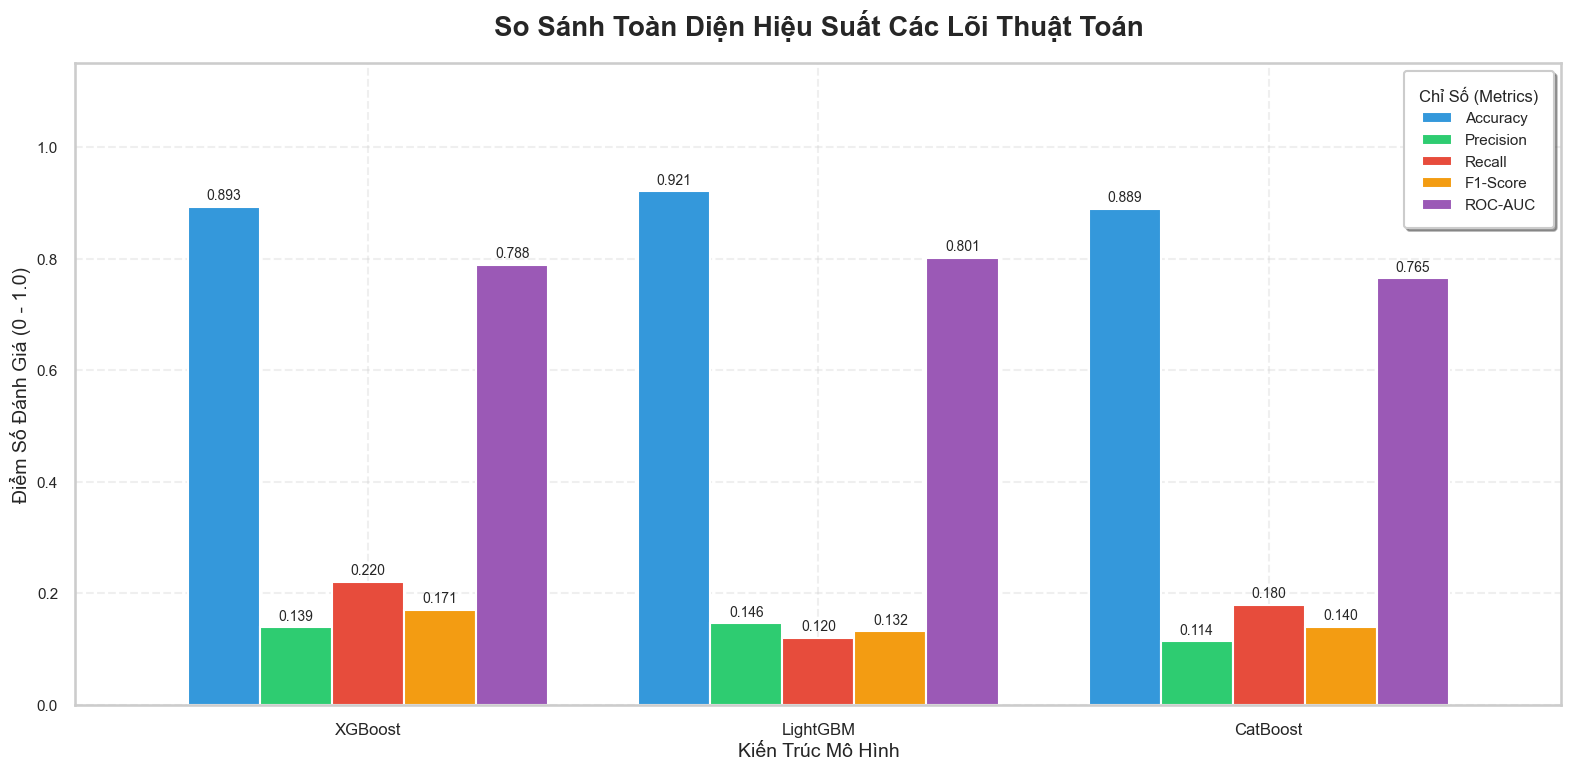

In [5]:
#SO SÁNH CÁC MODEL

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Đặt style biểu đồ
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.9
)

# QUAN TRỌNG: Để tính ROC-AUC, ta cần cả y_pred (nhãn cứng 0/1) và y_pred_proba (xác suất %)
# Giả định bạn đã chạy các mô hình và có sẵn các biến này
models = {
    
    'XGBoost': (y_pred_XGB, y_pred_proba_XGB),
    'LightGBM': (y_pred_LGBM, y_pred_proba_LGBM),
    'CatBoost': (y_pred_cat, y_pred_proba_cat)
}

results = []

# Vòng lặp tính toán 5 chỉ số
for name, (pred, proba) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba) # <<< CHỈ SỐ QUAN TRỌNG NHẤT TRONG Y TẾ
    })

results_df = pd.DataFrame(results)

# Hiển thị kết quả dạng bảng trên console
print("\n" + "="*80)
print("BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH DỰ ĐOÁN ĐỘT QUỴ")
print("="*80)
# Sắp xếp ưu tiên theo Recall vì chúng ta đang ưu tiên "Không bỏ sót bệnh nhân"
print(results_df.sort_values('Recall', ascending=False).to_string(index=False))

# ==========================================
# VẼ BIỂU ĐỒ SO SÁNH (BAR CHART)
# ==========================================
plt.figure(figsize=(15, 8))

# Chọn màu cho 5 chỉ số (Thêm màu tím cho ROC-AUC)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# Vẽ biểu đồ
ax = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(16, 8), # Kéo rộng ngang một chút để chứa 5 cột/mô hình
    width=0.8,
    color=colors
)

plt.title(
    'So Sánh Toàn Diện Hiệu Suất Các Lõi Thuật Toán',
    fontsize=20,
    fontweight='bold',
    pad=20
)
plt.ylabel('Điểm Số Đánh Giá (0 - 1.0)', fontsize=14, fontweight='medium')
plt.xlabel('Kiến Trúc Mô Hình', fontsize=14, fontweight='medium')

# Đặt giới hạn trục Y cao hơn chút để nhường chỗ cho text nhãn
plt.ylim(0, 1.15) 

# Gắn nhãn số liệu lên đầu mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10, fontweight='medium')

# Cấu hình chú thích (Legend)
legend = plt.legend(
    title='Chỉ Số (Metrics)',
    title_fontsize=12,
    fontsize=11,
    loc='upper right', # Chuyển sang góc phải để đỡ bị lấn chữ
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=1
)

plt.xticks(
    rotation=0,
    fontsize=12,
    fontweight='medium'
)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Lưu ảnh chất lượng cao để chèn vào báo cáo Word/Slide (Tùy chọn)
plt.savefig('model_comparison_benchmark.png', dpi=300, bbox_inches='tight')

plt.show()

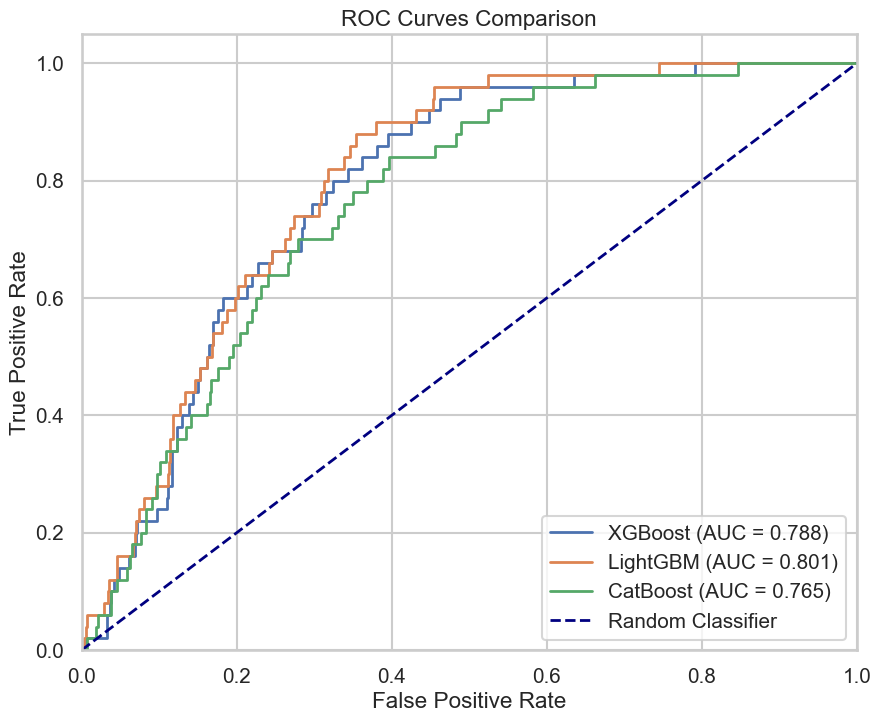

: 

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Vẽ ROC cho từng mô hình
models_proba = {
    'XGBoost': model.predict_proba(X_test)[:, 1],
    'LightGBM': lgbm_model.predict_proba(X_test)[:, 1],
    'CatBoost': cat_model.predict_proba(X_test)[:, 1]
}

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [8]:
import joblib
import os

print("📦 Đang tiến hành đóng gói các mô hình AI...")



# 2. Lưu mô hình XGBoost (Biến của bạn tên là 'model')
joblib.dump(model, '../trained_models/xgboost_cdc_stroke_model.pkl')
print("✅ Đã lưu thành công: XGBoost")

# 3. Lưu mô hình LightGBM (Biến của bạn tên là 'lgbm_model')
# (Nếu bạn chưa chạy thành công LightGBM thì có thể thêm dấu # ở trước dòng này để ẩn nó đi)
joblib.dump(lgbm_model, '../trained_models/lightgbm_cdc_stroke_model.pkl')
print("✅ Đã lưu thành công: LightGBM")

# 4. Lưu mô hình CatBoost (Biến của bạn tên là 'cat_model')
# (Nếu bạn chưa chạy thành công CatBoost thì có thể thêm dấu # ở trước dòng này để ẩn nó đi)
joblib.dump(cat_model, '../trained_models/catboost_cdc_stroke_model.pkl')
print("✅ Đã lưu thành công: CatBoost")

print("🎉 Hoàn tất! Hãy kiểm tra thư mục 'trained_models' bên trái màn hình nhé.")

📦 Đang tiến hành đóng gói các mô hình AI...
✅ Đã lưu thành công: XGBoost
✅ Đã lưu thành công: LightGBM
✅ Đã lưu thành công: CatBoost
🎉 Hoàn tất! Hãy kiểm tra thư mục 'trained_models' bên trái màn hình nhé.
